# IT2011 — 2026-Y2-S1-KU-02
# Member 4: Jayalath S.V. (IT25100138)
## Technique: Normalization / Scaling

**Why it's needed for this dataset:** Raw pixel values are 8-bit integers (0–255). Gradient-based optimizers
(used to train the CNN) converge faster and more stably on small numeric ranges, and distance-based models
(used for the SVM) are sensitive to the absolute scale of input features. Rescaling to `[0, 1]` puts every
pixel on a common, small numeric scale without distorting the digit's shape.


## Setup

This notebook is self-contained: it loads MNIST itself and reproduces any minimal prerequisite steps from a
teammate's earlier pipeline stage (noted where relevant).


In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import mnist

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)


Training images: (60000, 28, 28) | Training labels: (60000,)
Test images:     (10000, 28, 28) | Test labels:     (10000,)


In [10]:
print("Before normalization:")
print(f"  Min = {X_train.min()}, Max = {X_train.max()}, Mean = {X_train.mean():.2f}")

X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("\nAfter normalization:")
print(f"  Min = {X_train_norm.min()}, Max = {X_train_norm.max()}, Mean = {X_train_norm.mean():.4f}")


Before normalization:
  Min = 0, Max = 255, Mean = 33.32

After normalization:
  Min = 0.0, Max = 1.0, Mean = 0.1307


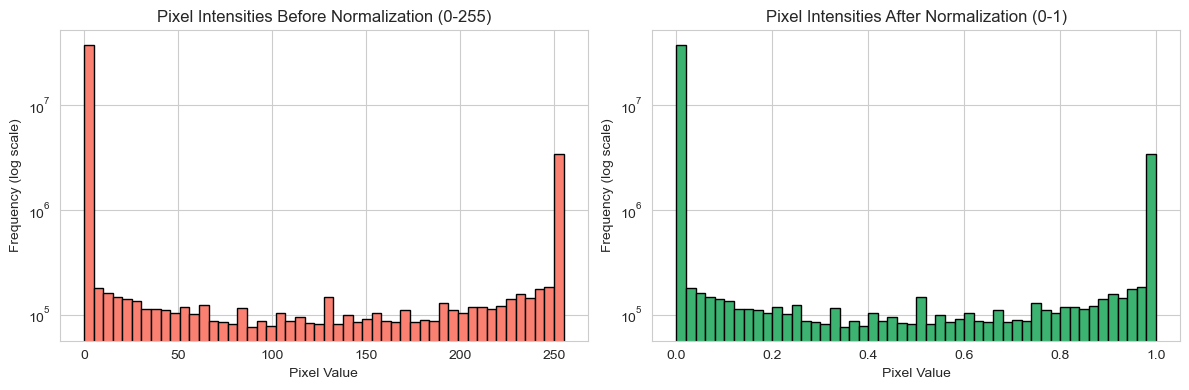

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train.flatten(), bins=50, color='salmon', edgecolor='black')
axes[0].set_title("Pixel Intensities Before Normalization (0-255)")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_yscale('log')

axes[1].hist(X_train_norm.flatten(), bins=50, color='mediumseagreen', edgecolor='black')
axes[1].set_title("Pixel Intensities After Normalization (0-1)")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/04_normalization.png', bbox_inches='tight')
plt.show()


**Interpretation:** The distribution is strongly bimodal in both plots — mostly pure background (value 0 /
near 0) with a smaller cluster of ink-covered foreground pixels near the max — and that shape is preserved
after scaling, only the numeric range changes. This confirms the transformation is a pure rescale, not a
distortion of the underlying signal.
